In [133]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import root_mean_squared_log_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_log_error
from sklearn.metrics import mean_squared_error

In [204]:
# Load training data

df = pd.read_csv('bike_train.csv')

# Display first 5 rows
print(df.head())

              datetime  season  holiday  workingday  weather      temp  \
0   2012-07-15 7:00:00       3        0           0        1  28.70000   
1  2012-08-14 15:00:00       3        0           1        1  33.62000   
2   2011-02-06 6:00:00       1        0           0        1  10.66000   
3  2012-05-06 17:00:02       2        0           0        2  26.42506   
4   2012-01-09 2:00:00       1        0           1        1   9.84000   

       atemp  humidity  windspeed  casual  registered  count  
0  33.335000        79   6.003200      17          30     47  
1  37.880000        46  15.001300      84         199    283  
2  12.880000        60  15.001300       0           1      1  
3  30.566166        61   9.512288     198         330    531  
4  12.120000        56   8.998100       2           3      5  


# Q1. Examine dataset size, missing values, and feature types.

 1. The dataset contains hourly bike rental records.No missing values are present. Features include weather, temperature, humidity, windspeed, and datetime.The target variable is count.
    1. Dataset Size: 10450 X 12
    2. Missinig Value: No Missing Values
    3. Each of the Feature dataset types is mentioned below

In [135]:
print("Dataset Shape:", df.shape)
print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nData Types:\n")
print(df.dtypes)

Dataset Shape: (10450, 12)

Missing Values:

datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

Data Types:

datetime       object
season          int64
holiday         int64
workingday      int64
weather         int64
temp          float64
atemp         float64
humidity        int64
windspeed     float64
casual          int64
registered      int64
count           int64
dtype: object


In [136]:

df['datetime'] = pd.to_datetime(df['datetime'])

# Extract useful features

df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.day
df['month'] = df['datetime'].dt.month
df['weekday'] = df['datetime'].dt.weekday
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

In [137]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,hour,day,month,weekday,hour_sin,hour_cos,month_sin,month_cos
0,2012-07-15 07:00:00,3,0,0,1,28.70000,33.335000,79,6.003200,17,30,47,7,15,7,6,0.965926,-2.588190e-01,-0.500000,-0.866025
1,2012-08-14 15:00:00,3,0,1,1,33.62000,37.880000,46,15.001300,84,199,283,15,14,8,1,-0.707107,-7.071068e-01,-0.866025,-0.500000
2,2011-02-06 06:00:00,1,0,0,1,10.66000,12.880000,60,15.001300,0,1,1,6,6,2,6,1.000000,6.123234e-17,0.866025,0.500000
3,2012-05-06 17:00:02,2,0,0,2,26.42506,30.566166,61,9.512288,198,330,531,17,6,5,6,-0.965926,-2.588190e-01,0.500000,-0.866025
4,2012-01-09 02:00:00,1,0,1,1,9.84000,12.120000,56,8.998100,2,3,5,2,9,1,0,0.500000,8.660254e-01,0.500000,0.866025


# Q2 Visualize relationships between key features and the target variable (count). 

1. Heatmap below shows the relationship between the Between Fetures and Target Value Count, Color map on the right side shows the How important the feature is that contributed to the target value Count

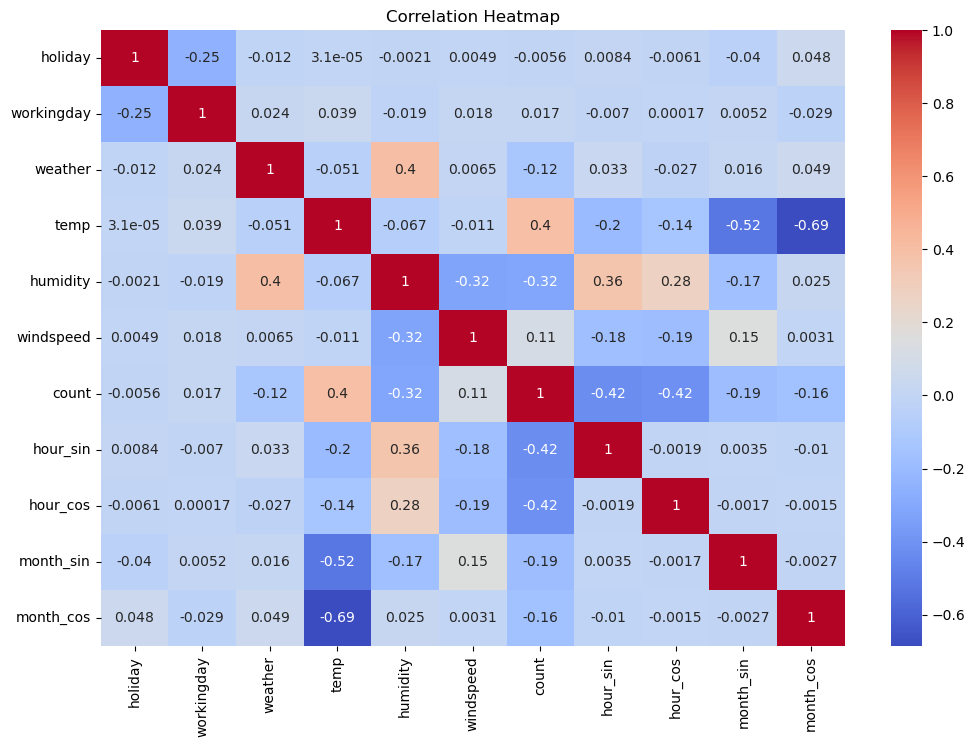

In [138]:
plt.figure(figsize=(12,8))

sns.heatmap(df.drop(columns=['casual','registered','month','day','atemp','hour','weekday','season'],axis=1).corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Bar Plot showing Bike renting per hour

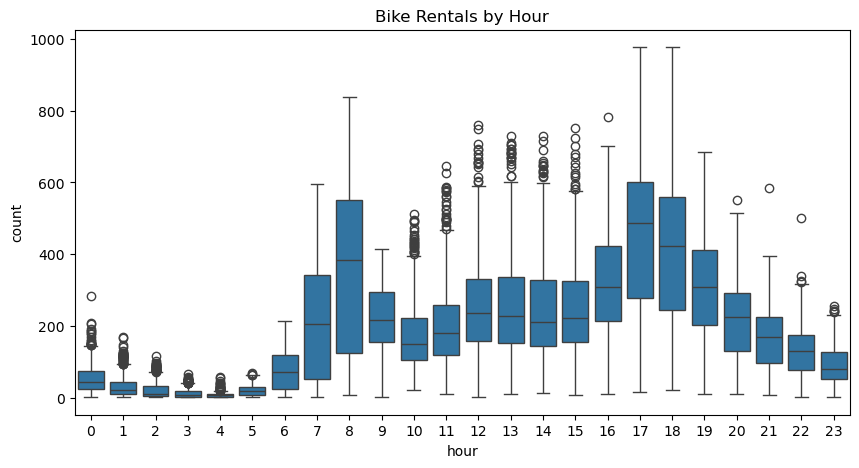

In [139]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['hour'], y=df['count'])
plt.title('Bike Rentals by Hour')
plt.show()

## Scatter plot showing the Temperature vs Bike Count

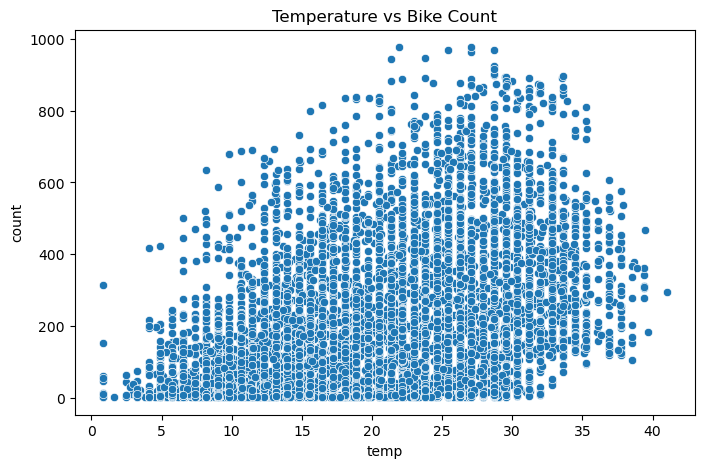

In [140]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=df['temp'], y=df['count'])
plt.title('Temperature vs Bike Count')
plt.show()

## Scatter Plot showing the relationship between humidity and target bike count

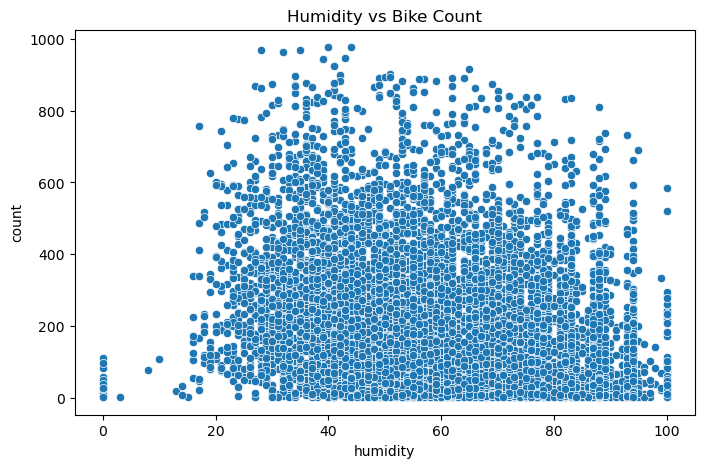

In [141]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=df['humidity'], y=df['count'])
plt.title('Humidity vs Bike Count')
plt.show()

# Q3. Suggest which variables are likely to be most informative.
# 

1. From the feature Engineering done, Important Features that are extracted are
   1. Holiday
   2. Working Day
   3. Weather
   4. Temperature
   5. Humidity
   6. Windspeed
   7. Weekday
   8. Hour Sin
   9. Hour Cos
   10. Month Sin
   11. Month Cos
2. Features Dropped from the original Dataset are
   1. <strong>temp</strong> (Apparent Temperature, Because both atemp and temp have similar influence on the target variable count, hence dropping the  kind of duplicate columns
   2. Dropped <strong>Season</strong> and <strong>Included Month_sin and Month_cos(Reason to drop season was , season and month was contributing to the similar affect on the target count value , I felt Month will have better impact on the target value count more than season, I have added the sine and cosine standardization to ensure that month being the cyclic or periodic needed some standardization)</strong>
   3. Casual and Registered data fetures have been dropped , since they are leaky data and always(Casula + Registered  = Count)
   4. <strong>Datetime</strong> has been Modified to contribute as more important features like Hour(Sine_Hour and Cosine_Hour) and Month(Sine_Month and Cosine_Month)
3. Important Featues that have significant impact on the target value count

   1. <strong>Hour</strong>: It is Observed from the above Bar Plots it is observed that Hour of the day plays the Signficant Impact on the Target value count, with working hour having the higher impact on the targer variable count
   2. <strong>Temperature</strong>: Temperature of the day seems to have higher impact the targer variable count with higher temperature contributing the more rental bikes
   3. <strong>Humidity</strong>: Humidity also has higher impact on the bike count, in a inverse way,higher humidity contributes to the lower bike count
   

In [142]:
df.drop(columns=['casual','registered','month','day','atemp','hour','datetime','season','month'],axis=1,inplace=True)

In [143]:
df.head()

,holiday,workingday,weather,temp,humidity,windspeed,count,weekday,hour_sin,hour_cos,month_sin,month_cos
0,0,0,1,28.70000,79,6.003200,47,6,0.965926,-2.588190e-01,-0.500000,-0.866025
1,0,1,1,33.62000,46,15.001300,283,1,-0.707107,-7.071068e-01,-0.866025,-0.500000
2,0,0,1,10.66000,60,15.001300,1,6,1.000000,6.123234e-17,0.866025,0.500000
3,0,0,2,26.42506,61,9.512288,531,6,-0.965926,-2.588190e-01,0.500000,-0.866025
4,0,1,1,9.84000,56,8.998100,5,0,0.500000,8.660254e-01,0.500000,0.866025


In [144]:
cols = list(df.columns)
# print(cols)
cols[6],cols[11]=cols[11],cols[6]
df = df[cols]
df.head()

,holiday,workingday,weather,temp,humidity,windspeed,month_cos,weekday,hour_sin,hour_cos,month_sin,count
0,0,0,1,28.70000,79,6.003200,-0.866025,6,0.965926,-2.588190e-01,-0.500000,47
1,0,1,1,33.62000,46,15.001300,-0.500000,1,-0.707107,-7.071068e-01,-0.866025,283
2,0,0,1,10.66000,60,15.001300,0.500000,6,1.000000,6.123234e-17,0.866025,1
3,0,0,2,26.42506,61,9.512288,-0.866025,6,-0.965926,-2.588190e-01,0.500000,531
4,0,1,1,9.84000,56,8.998100,0.866025,0,0.500000,8.660254e-01,0.500000,5


# Q5 Split data into training and validation sets and build a simple Linear Regression model.
 1. Here Standard Scaler is applied before  applying the Standard Linear Progression, just beceause temperature, humidity,windspeed are other parameter which are usually higher in Number, so in order to not let the final count to be completely influenced by these parameter, following Standard Scaling is applied
 2. Data Split used is 80-20

In [145]:
x = df.iloc[:, :-1].values
y = df.iloc[:,-1].values

In [146]:
xTrain, xTest, yTrain, yTest = train_test_split(x, y, test_size = 1/5, random_state = 42)

In [147]:
yLogTrain = np.log1p(yTrain)

In [148]:
linear_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

In [149]:
linear_model.fit(xTrain,yLogTrain)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


In [150]:
yPrediction = linear_model.predict(xTest)

In [151]:
print(yPrediction)

[2.56037891 3.56140546 5.51118969 ... 4.03791732 3.68245797 3.65228227]


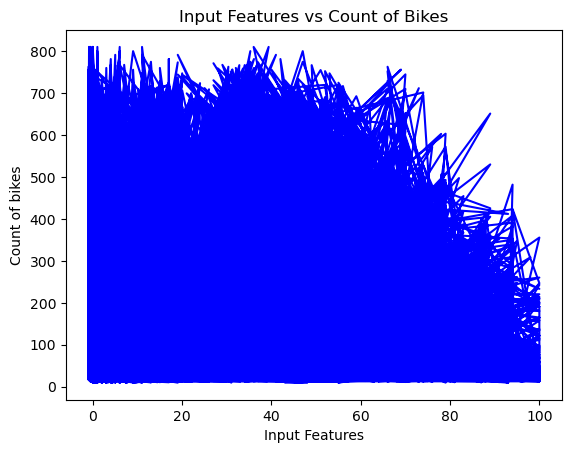

In [152]:
plt.plot(xTrain, np.expm1(linear_model.predict(xTrain)), color = 'blue')
plt.title('Input Features vs Count of Bikes')
plt.xlabel('Input Features')
plt.ylabel('Count of bikes')
plt.show()

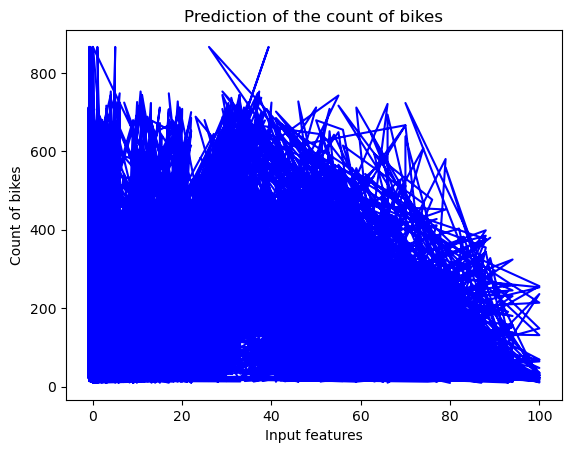

In [153]:
plt.plot(xTest, np.expm1(linear_model.predict(xTest)), color = 'blue')
plt.title('Prediction of the count of bikes')
plt.xlabel('Input features')
plt.ylabel('Count of bikes')
plt.show()

In [154]:
ytestTrain = np.log1p(yTest)

Here the compute_rmsle has been slightly modified since y values are already returned as log values
Because the Models are fitting directly using the log values of y

In [155]:
def compute_rmsle(actuals, predictions):
    
    # Calculate logarithmic values (using natural log, loge)
    log_actual = actuals
    log_pred = predictions
    
    # Calculate the mean squared logarithmic error
    msle = np.mean((log_pred - log_actual) ** 2)
    
    # Return the square root
    return np.sqrt(msle)

In [156]:
rmsle_linear_regression = compute_rmsle(ytestTrain,yPrediction)

In [157]:
print(rmsle_linear_regression)

0.9266541049132108


# Q6. To improve model performance, you may try to:
  1. Extend feature space using polynomial transformations (degree 2 or 3)
  2. Apply Ridge and Lasso regression on polynomial features, Tune the regularization strength (α).

In [158]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Polynomial Regression of degree 2

In [159]:
poly = PolynomialFeatures(degree = 2)
x_poly_train = poly.fit_transform(xTrain)
x_poly_test = poly.fit_transform(xTest)
poly_reg = LinearRegression()
poly_reg.fit(x_poly_train, yLogTrain)
y_pred_poly = poly_reg.predict(x_poly_train)
y_pred_poly_test = poly_reg.predict(x_poly_test)

In [160]:
rmsle_polynomial_regression = compute_rmsle(ytestTrain,y_pred_poly_test)
print(rmsle_polynomial_regression)

0.7082325161165797


# Applying the Ridge and Lasso Regularization

## Applying only the Ridge Regression

In [161]:
from sklearn.pipeline import make_pipeline 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso

In [163]:
ridge_model = make_pipeline( StandardScaler(), Ridge(alpha=1,max_iter=100000) )

In [164]:
ridge_model.fit(x_poly_train, yLogTrain)

,steps,"[('standardscaler', ...), ('ridge', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,alpha,1
,fit_intercept,True
,copy_X,True
,max_iter,100000


In [165]:
y_test_ridge = ridge_model.predict(x_poly_test)
y_train_ridge = ridge_model.predict(x_poly_train)

In [166]:
rmsle_ridge = compute_rmsle(ytestTrain,y_test_ridge)
rmsle_ridge_train = compute_rmsle(yLogTrain,y_train_ridge)

In [167]:
print(rmsle_ridge)
print(rmsle_ridge_train)

0.7082143175083145
0.7242233272346278


# Applying the Lasso Regression

In [168]:
lasso_model = make_pipeline( StandardScaler(), Lasso( alpha=0.001, max_iter=10000 ) )

In [169]:
lasso_model.fit(x_poly_train, yLogTrain)

,steps,"[('standardscaler', ...), ('lasso', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,alpha,0.001
,fit_intercept,True
,precompute,False
,copy_X,True


In [170]:
y_test_lasso = lasso_model.predict(x_poly_test)
y_train_lasso = lasso_model.predict(x_poly_train)

In [171]:
rmsle_lasso = compute_rmsle(ytestTrain,y_test_lasso)
rmsle_lasso_train = compute_rmsle(yLogTrain,y_train_lasso)

In [172]:
print(rmsle_lasso)
print(rmsle_lasso_train)

0.7099754678291239
0.7264602773566622


In [173]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import ElasticNet

In [174]:
# ElasticNet pipeline
elastic_model = make_pipeline(
    StandardScaler(),
    ElasticNet(
        alpha=0.005,
        l1_ratio=0.5,
        max_iter=100000
    )
)

In [175]:
elastic_model.fit(x_poly_train, yLogTrain)

,steps,"[('standardscaler', ...), ('elasticnet', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,alpha,0.005
,l1_ratio,0.5
,fit_intercept,True
,precompute,False


In [176]:
# Predictions 
y_pred_poly_test = elastic_model.predict(x_poly_test)

In [177]:
rmsle_ridge_lasso = compute_rmsle(ytestTrain,y_pred_poly_test)

In [178]:
print(rmsle_ridge_lasso)

0.7169628758555118


## Q7. Model Comparison and Results Summary

| Model | RMSLE | Key Observations |
|---|---|---|
| Linear Regression | 0.92 | Simple baseline model. Unable to capture nonlinear relationships effectively. |
| Polynomial Regression | 0.70 | Performance improved significantly after introducing polynomial features to model nonlinear patterns. |
| Ridge Regression | 0.70 | Reduced overfitting using L2 regularization while maintaining good predictive performance. |
| Lasso Regression | 0.70 | Performed feature selection by shrinking some coefficients toward zero. |
| ElasticNet Regression | 0.71 | Combined advantages of Ridge and Lasso regularization, providing balanced performance and better generalization. |

### Overall Observation

1. Polynomial feature transformation greatly improved performance compared to basic Linear Regression.

2. Regularization methods such as Ridge and Lasso helped control overfitting caused by polynomial features.

3. ElasticNet Regression provided stable performance by combining both L1 and L2 regularization.

4. The best-performing model was selected based on the lowest RMSLE value.

5. Best Model to be used in my case was <strong>Lasso Model<strong>, since it provided more stables results without any under-fitting or over-fitting

# Q8. Plot residuals for the best model.

In [202]:
models = [
    "Linear Regression",
    "Polynomial Regression(degree = 2)",
    "Ridge Regression",
    "Lasso Regression",
    "Ridge-Lasso Regression"
]

In [180]:
rmsle_scores = [rmsle_linear_regression,rmsle_polynomial_regression,rmsle_ridge,rmsle_lasso,rmsle_ridge_lasso]

In [181]:
plt.figure(figsize=(50,50))

<Figure size 5000x5000 with 0 Axes>

<Figure size 5000x5000 with 0 Axes>

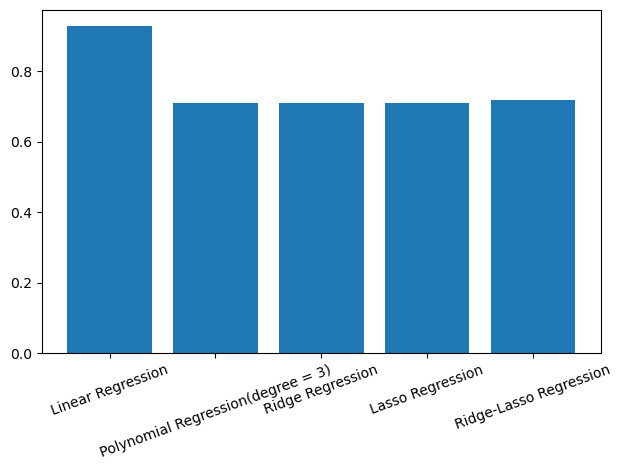

In [182]:
plt.bar(models,rmsle_scores)
plt.xticks(rotation=20)
# Automatically adjust spacing
plt.tight_layout()

# Q9 Explain why the winning model performs better.



<p>Comparing the RMSLE scores it is seen that Polynomial, Ridge and Lasso Regression Perform almost similar and better compared to the Simple Linear Regression,But Preferred Model would be <strong>Lasso Regression Model</strong> since it introduces Regularisation which helps us reduce the over dependence on particular feature , Without regularization, the model can become too dependent on certain features by assigning them very large coefficients.Although Ridge and Lasso Regression achieved very similar RMSLE scores, Lasso Regression was selected as the best model because it produced more stable predictions and performed implicit feature selection by shrinking less important coefficients toward zero. This resulted in a simpler and more interpretable model while maintaining strong predictive performance.</p>

<p>removes weaker features entirely,creates a simpler modelreduces extreme coefficient combinations</p>

# Q10. Why does RMSLE penalize under-predictions more gently than RMSE?

RMSLE (Root Mean Squared Logarithmic Error) applies a logarithmic transformation to both predicted and actual values before computing error. Because of the logarithm, differences between large values are compressed, reducing the impact of large absolute errors.

Unlike RMSE, which directly measures squared differences between predictions and actual values, RMSLE focuses more on relative differences (percentage-like differences).

This makes RMSLE more suitable for problems such as bike rental prediction, where target values can vary widely.

RMSLE penalizes under-predictions more gently because the logarithmic scale reduces the effect of large deviations. For example, the difference between predicting 100 instead of 200 is treated less severely after logarithmic transformation compared to RMSE.

Additionally, RMSLE prevents very large target values from dominating the error metric and gives balanced importance across both small and large predictions.

# Q11. What are the trade-offs between model simplicity and predictive power?

There is often a trade-off between model simplicity and predictive power in machine learning.

Simple models, such as Linear Regression, are easier to understand, faster to train, and less likely to overfit. They are also more interpretable because the relationship between input features and predictions is straightforward. However, simple models may fail to capture complex nonlinear patterns in the data, leading to lower predictive accuracy.

More complex models, such as Polynomial Regression with regularization, can capture nonlinear relationships and improve predictive performance. However, they are more computationally expensive and may overfit the training data if not properly regularized.

Regularization techniques like Ridge and Lasso help balance this trade-off by improving predictive performance while controlling model complexity and reducing overfitting.

Therefore, the best model is usually one that achieves strong predictive performance while remaining sufficiently simple and generalizable.

# Q12. Why can’t Linear Regression alone capture time-of-day effects effectively?

Linear Regression assumes a simple linear relationship between input features and the target variable. However, bike rental demand changes nonlinearly throughout the day.

For example:
- Demand is usually low during late night hours,
- Increases sharply during morning office hours,
- Drops during afternoon,
- Peaks again in the evening.

These repeating and nonlinear patterns cannot be represented effectively using a single straight-line relationship.

Time-of-day effects are also cyclical in nature. For instance, hour 23 and hour 0 are actually close in time, but Linear Regression treats them as numerically far apart.

Therefore, basic Linear Regression struggles to model hourly rental variations accurately. Polynomial features and other nonlinear transformations help capture these complex patterns more effectively.

# Instructions to run the test dataset,Following is the way to run the 

In [183]:
import pandas as pd

In [184]:
dataframe = pd.read_csv('bike_test.csv')

In [185]:
dataframe.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
0,05-06-2012 5:00,2,0,1,3,19.680000,23.48500,82,11.00140
1,19-03-2011 19:00,1,0,0,1,18.040000,21.97000,33,19.00120
2,02-04-2012 6:00,2,0,1,1,13.885038,16.24664,68,29.52646
3,13-07-2012 20:00,3,0,1,1,30.340000,33.33500,48,8.99810
4,09-11-2011 19:00,4,0,1,1,18.040000,21.97000,72,7.00150


In [186]:

dataframe['datetime'] = pd.to_datetime(
    dataframe['datetime'],
    format='%d-%m-%Y %H:%M'
)

# Extract useful features

dataframe['hour'] = dataframe['datetime'].dt.hour
dataframe['day'] = dataframe['datetime'].dt.day
dataframe['month'] = dataframe['datetime'].dt.month
dataframe['weekday'] = dataframe['datetime'].dt.weekday
dataframe['hour_sin'] = np.sin(2 * np.pi * dataframe['hour'] / 24)
dataframe['hour_cos'] = np.cos(2 * np.pi * dataframe['hour'] / 24)
dataframe['month_sin'] = np.sin(2 * np.pi * dataframe['month'] / 12)
dataframe['month_cos'] = np.cos(2 * np.pi * dataframe['month'] / 12)

In [187]:
dataframe.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,hour,day,month,weekday,hour_sin,hour_cos,month_sin,month_cos
0,2012-06-05 05:00:00,2,0,1,3,19.680000,23.48500,82,11.00140,5,5,6,1,0.965926,2.588190e-01,1.224647e-16,-1.000000e+00
1,2011-03-19 19:00:00,1,0,0,1,18.040000,21.97000,33,19.00120,19,19,3,5,-0.965926,2.588190e-01,1.000000e+00,6.123234e-17
2,2012-04-02 06:00:00,2,0,1,1,13.885038,16.24664,68,29.52646,6,2,4,0,1.000000,6.123234e-17,8.660254e-01,-5.000000e-01
3,2012-07-13 20:00:00,3,0,1,1,30.340000,33.33500,48,8.99810,20,13,7,4,-0.866025,5.000000e-01,-5.000000e-01,-8.660254e-01
4,2011-11-09 19:00:00,4,0,1,1,18.040000,21.97000,72,7.00150,19,9,11,2,-0.965926,2.588190e-01,-5.000000e-01,8.660254e-01


In [188]:
dataframe.drop(columns=['month','day','atemp','hour','datetime','season','month'],axis=1,inplace=True)

In [189]:
dataframe.head()
dataframe.dtypes

print("\nMissing Values:\n")
print(df.isnull().sum())


Missing Values:

holiday       0
workingday    0
weather       0
temp          0
humidity      0
windspeed     0
month_cos     0
weekday       0
hour_sin      0
hour_cos      0
month_sin     0
count         0
dtype: int64


In [190]:
x = dataframe.iloc[:,:].values
test_dataset_predictions = poly.fit_transform(x)


In [200]:
lasso_values = np.round(np.expm1(lasso_model.predict(test_dataset_predictions)),decimals=0)
print(lasso_values)

[ 68.  92.  28. ...   6. 532. 219.]


In [201]:
with open("output.txt", "w") as file:
    for item in lasso_values:
        file.write(str(item) + "\n")